In [1]:

import os

# This forces OpenMP to use 1 single thread, which is needed to
# prevent contention between multiple process.
os.environ['OMP_NUM_THREADS'] = '1'
# Tell numpy to only use one core.
os.environ['MKL_NUM_THREADS'] = '1'

import sys
from absl import flags

import numpy as np
import torch


FLAGS = flags.FLAGS

flags.DEFINE_integer('board_size', 9, 'Board size for Go.')
flags.DEFINE_float('komi', 7.5, 'Komi rule for Go.')
flags.DEFINE_integer(
    'num_stack',
    8,
    'Stack N previous states, the state is an image of N x 2 + 1 binary planes.',
)

flags.DEFINE_integer(
    'num_simulations',
    200,
    'Number of simulations per MCTS search, this applies to both self-play and evaluation processes.',
)

flags.DEFINE_integer(
    'num_parallel',
    6,
    'Number of leaves to collect before using the neural network to evaluate the positions during MCTS search,'
    '1 means no parallel search.',
)
flags.DEFINE_float(
    'c_puct_base',
    19652,
    'Exploration constants balancing priors vs. search values. Original paper use 19652',
)
flags.DEFINE_float(
    'c_puct_init',
    1.25,
    'Exploration constants balancing priors vs. search values. Original paper use 1.25',
)

flags.DEFINE_float(
    'default_rating',
    1500,
    'Default elo rating, change to the rating (for black) from last checkpoint when resume training.',
)
flags.DEFINE_string(
    'logs_dir',
    './logs/go/5x5/alphago_series',
    'Path to save statistics for self-play, training, and evaluation.',
)
flags.DEFINE_string('log_level', 'INFO', '')
flags.DEFINE_integer('seed', 1, 'Seed the runtime.')
# Initialize flags
FLAGS(sys.argv, known_only = True)

os.environ['BOARD_SIZE'] = str(FLAGS.board_size)

In [2]:
from alpha_zero.envs.go import GoEnv
from alpha_zero.core.pipeline import (
    set_seed,
    maybe_create_dir,
)
from alpha_zero.core.multi_game import run_tournament
from alpha_zero.core.quantum_net import QuantumAlphaZeroNet, SoftHardSearchAlphaZeroNet
from alpha_zero.core.network import AlphaZeroNet
from alpha_zero.utils.util import extract_args_from_flags_dict, create_logger

Plink failed to import tkinter.


In [3]:
# Build environment once
eval_env = GoEnv(komi=FLAGS.komi, num_stack=FLAGS.num_stack)
input_shape = eval_env.observation_space.shape
num_actions = eval_env.action_space.n

In [4]:
agent_configs = [
    {
        'name': 'softsearch_1',
        'arch': 'softsearch',
        'num_filters': 128,
        'max_depth': 1,
        'branching_width': 3,
        'beam_width': 1,
        'num_fc_units': 128,
        'num_search': 5,
        'load_chkpt': './checkpoints_supervised/d1s5br3f128be1_soft/best_model.ckpt'
    },

    {
        'name': 'softsearch_2',
        'arch': 'softsearch',
        'num_filters': 128,
        'max_depth': 1,
        'branching_width': 1,
        'beam_width': 1,
        'num_fc_units': 128,
        'num_search': 5,
        'load_chkpt': 'checkpoints_supervised/d1s5br1f128be1_soft/best_model.ckpt'
    },
    {
        'name': 'hybrid',
        'arch': 'hybridsearch',
        'num_filters': 128,
        'max_depth': 1,
        'branching_width': 3,
        'beam_width': 3,
        'num_fc_units': 128,
        'num_search': 5,
        'load_chkpt': './checkpoints_supervised/d1s5br3f128be3_hybrid/best_model.ckpt'
    },

     {
        'name': 'resnet_5',
        'num_res_blocks': 5,
        'num_filters_resnet': 128,
        'arch': 'resnet',
        'num_fc_units':128,
        'load_chkpt' : './checkpoints_supervised/resnet_5/training_steps_10500.ckpt'
    },

]






In [5]:
def build_network(cfg):
    if cfg['arch'] == 'softsearch':
        return QuantumAlphaZeroNet(
            input_shape,
            num_actions,
            cfg['num_filters'],
            cfg['max_depth'],
            cfg['branching_width'],
            cfg['beam_width'],
            cfg['num_fc_units'],
            cfg['num_search'],
        )

    elif cfg['arch'] == 'hybridsearch':
        return SoftHardSearchAlphaZeroNet(
            input_shape,
            num_actions,
            cfg['num_filters'],
            cfg['max_depth'],
            cfg['branching_width'],
            cfg['beam_width'],
            cfg['num_fc_units'],
            cfg['num_search'],
        )
    else:
       return AlphaZeroNet(
            input_shape,
            num_actions,
            cfg['num_res_blocks'],
            cfg['num_filters_resnet'],
            cfg['num_fc_units'],
        )

In [6]:
Agents = {
    cfg["name"]: {
        "network": build_network(cfg),
        "elo_rating": 1500,
        "checkpoint": cfg["load_chkpt"],
        "wins": 0,
        "lost": 0
    }
    for cfg in agent_configs
}

In [7]:
set_seed(FLAGS.seed)

logger = create_logger(FLAGS.log_level)

logger.info(extract_args_from_flags_dict(FLAGS.flag_values_dict()))

INFO 2025-06-03 19:08:26 405228650.py:5] {'board_size': 9, 'komi': 7.5, 'num_stack': 8, 'num_simulations': 200, 'num_parallel': 6, 'c_puct_base': 19652.0, 'c_puct_init': 1.25, 'default_rating': 1500.0, 'logs_dir': './logs/go/5x5/alphago_series', 'log_level': 'INFO', 'seed': 1}


games played:   0%|          | 0/4000 [00:00<?, ?it/s]INFO 2025-06-03 19:08:26 multi_game.py:323] Starting match between softsearch_2 and hybrid
INFO 2025-06-03 19:08:26 multi_game.py:324] Playing game 1/4000
/home/banashree/neural-search/alpha_zero/core/multi_game.py:339: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any us

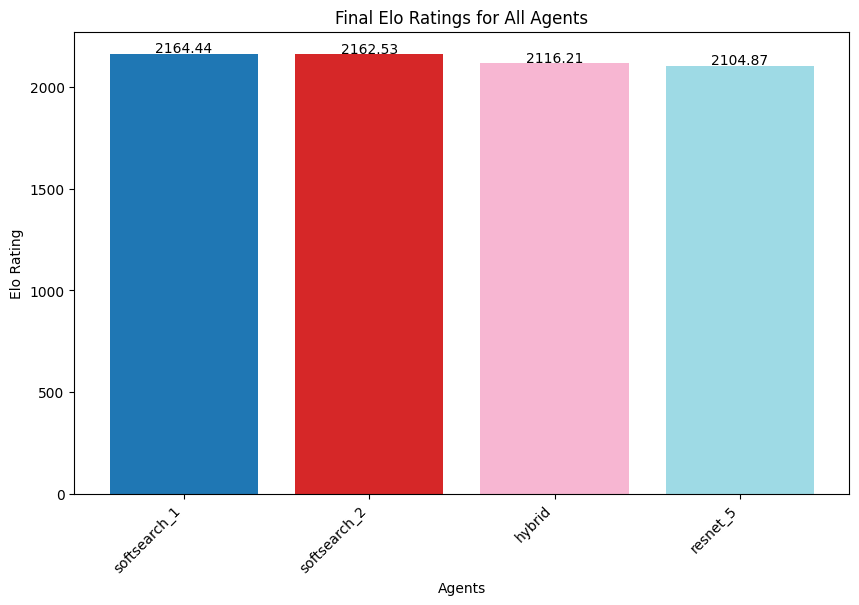

In [8]:
if torch.cuda.is_available():
    learner_device = torch.device('cuda')

run_tournament(
    seed = FLAGS.seed,
    agents = Agents,
    env = eval_env,
    device = learner_device,
    num_games = 1000*len(Agents),
    num_simulations = FLAGS.num_simulations,
    num_parallel = FLAGS.num_parallel,
    c_puct_base = FLAGS.c_puct_base,
    c_puct_init = FLAGS.c_puct_init,
    default_rating = FLAGS.default_rating,
    log_level = FLAGS.log_level,
    logs_dir = FLAGS.logs_dir,

)